In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

discharge = pd.read_csv('../data/prediction/prediction_discharge_vol.csv')
rain = pd.read_csv('../data/prediction/prediction_rain.csv')
temp_mean = pd.read_csv('../data/prediction/prediction_temperature_mean.csv')
waterlevel = pd.read_csv('../data/prediction/prediction_waterlevel.csv')

# Index setzen
for df in [discharge, rain, temp_mean, waterlevel]:
    df.set_index('date', inplace=True)
    df.dropna(inplace=True)

discharge = discharge.rename(columns={
    'trend': 'discharge_trend',
    'season': 'discharge_season',
    'seasonal': 'discharge_season', 
    'resid': 'discharge_resid'
})

rain = rain.rename(columns={
    'trend': 'rain_trend',
    'season': 'rain_season',
    'seasonal': 'rain_season',
    'resid': 'rain_resid'
})

temp_mean = temp_mean.rename(columns={
    'trend': 'temp_trend',
    'season': 'temp_season',
    'seasonal': 'temp_season',
    'resid': 'temp_resid'
})

waterlevel = waterlevel.rename(columns={
    'trend': 'wl_trend',
    'season': 'wl_season',
    'seasonal': 'wl_season',
    'resid': 'wl_resid'
})

df = (waterlevel
      .join(discharge, how='inner')
      .join(rain, how='inner')
      .join(temp_mean, how='inner'))

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df_train = df[:'2019-01-01']
df_test = df['2019-01-01':]


## Modellieren der Temperatur
Zuerst wollen wir die einzelnen Komponenten (Trend, Saisonalität, Residuen) der Temperatur modellieren.

### Modellierung Trend Temperatur

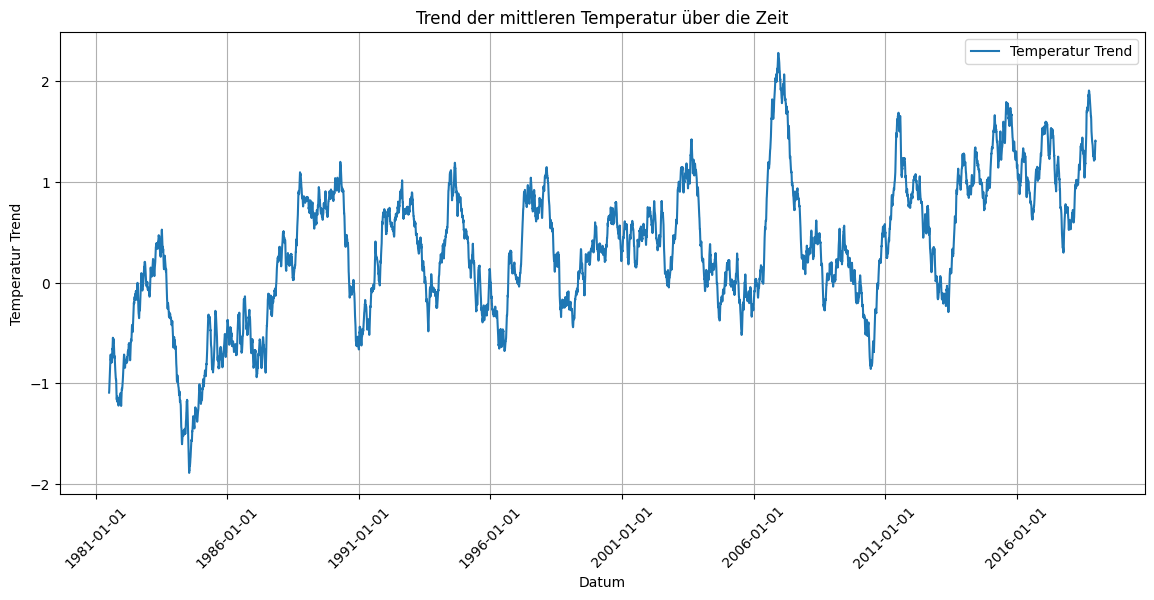

In [ ]:
# Trend der Temperatur modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
xticks = pd.date_range(
    start=df_train.index.min().replace(month=1, day=1),
    end=df_train.index.max(),
    freq='5YS'   # 5-year start frequency
)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_trend'], label='Temperatur Trend')
plt.xlabel('Datum')
plt.ylabel('Temperatur Trend')
plt.title('Trend der mittleren Temperatur über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

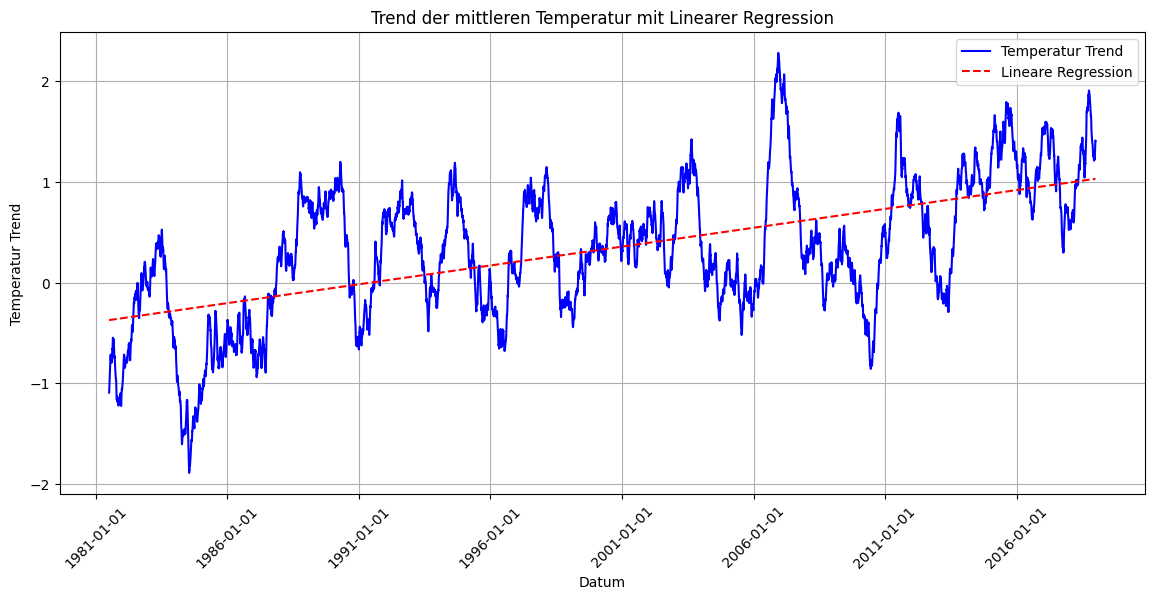

In [70]:
# Fitten einer Linearen Regression
from sklearn.linear_model import LinearRegression
# Umwandeln des Datums in eine numerische Darstellung (z.B. Tage seit Startdatum)
X = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
y = df_train['temp_trend'].values
temp_trend_model = LinearRegression()
temp_trend_model.fit(X, y)
temp_trend_pred = temp_trend_model.predict(X)

# Plotten des Trends und der linearen Regression
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_trend'], label='Temperatur Trend', color='blue')
plt.plot(df_train.index, temp_trend_pred, label='Lineare Regression', color='red', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Temperatur Trend')
plt.title('Trend der mittleren Temperatur mit Linearer Regression')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()


### Modellieren Saisonalität Temperatur

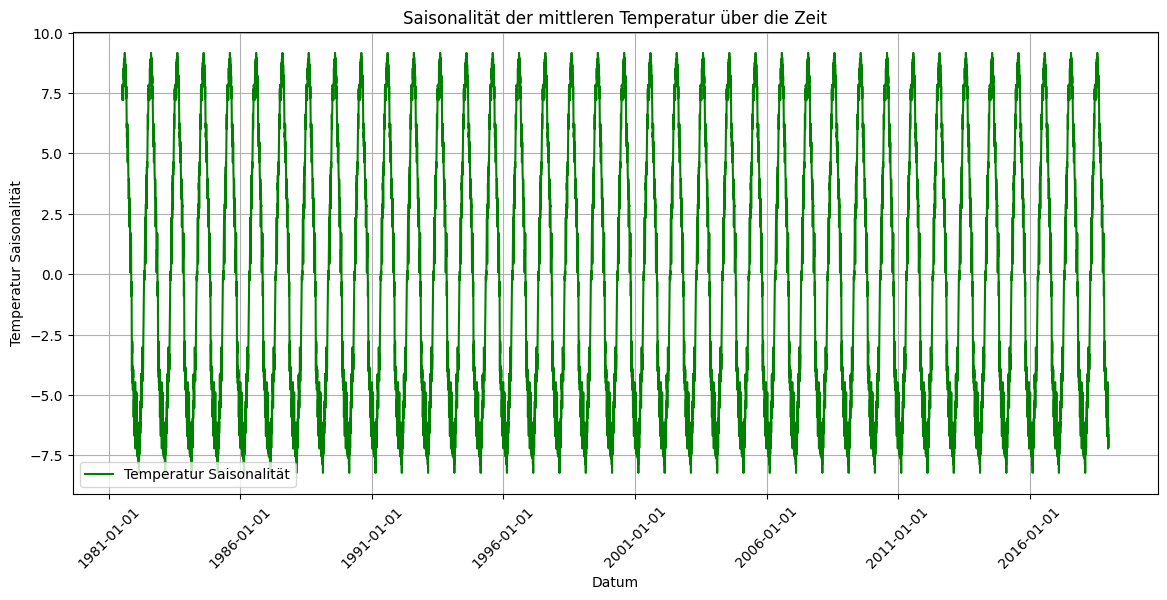

In [71]:
# Saisonalität der Tepmeratur plotten
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_season'], label='Temperatur Saisonalität', color='green')
plt.xlabel('Datum')
plt.ylabel('Temperatur Saisonalität')
plt.title('Saisonalität der mittleren Temperatur über die Zeit')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()

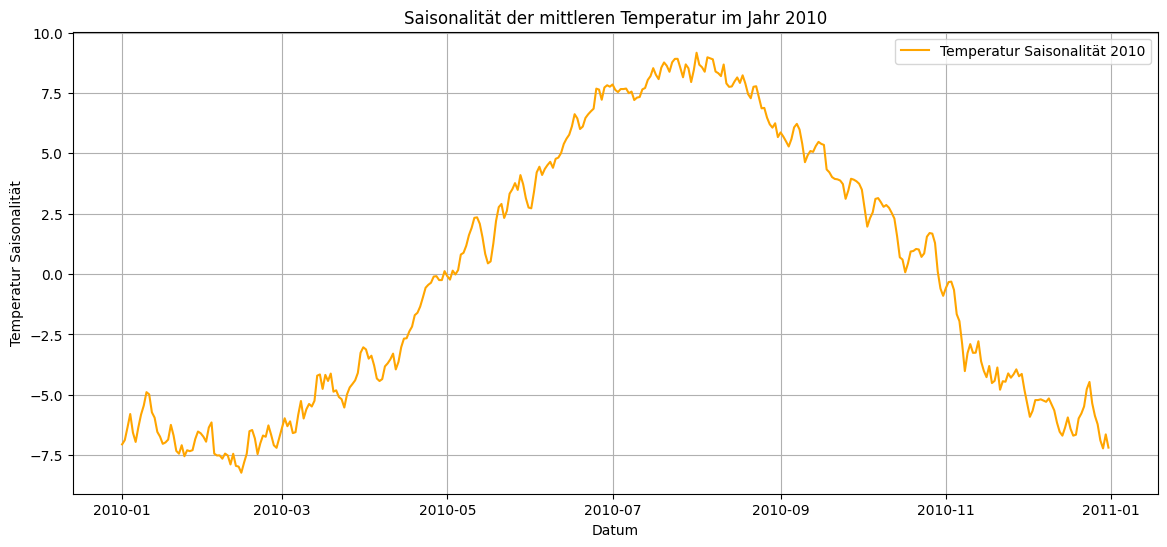

In [72]:
# Welle für ein Jahr plotten
plt.figure(figsize=(14, 6))
one_year = df_train['temp_season']['2010-01-01':'2010-12-31']
plt.plot(one_year.index, one_year.values, label='Temperatur Saisonalität 2010', color='orange')
plt.xlabel('Datum')
plt.ylabel('Temperatur Saisonalität')
plt.title('Saisonalität der mittleren Temperatur im Jahr 2010')
plt.grid(True)
plt.legend()
plt.show()


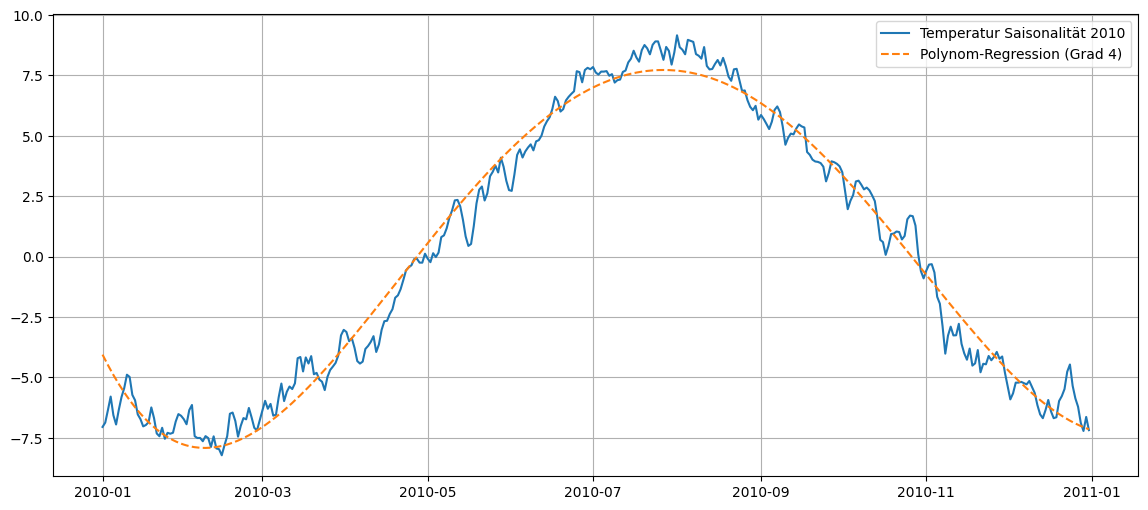

In [73]:
one_year = df_train['temp_season']['2010-01-01':'2010-12-31']

# Feature = Tag im Jahr (1–365)
day_of_year = one_year.index.dayofyear.values.reshape(-1, 1)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(day_of_year)

temp_season_model = LinearRegression()
temp_season_model.fit(X_poly, one_year.values)

season_pred = temp_season_model.predict(X_poly)

plt.figure(figsize=(14, 6))
plt.plot(one_year.index, one_year.values, label='Temperatur Saisonalität 2010')
plt.plot(one_year.index, season_pred, label='Polynom-Regression (Grad 4)', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()


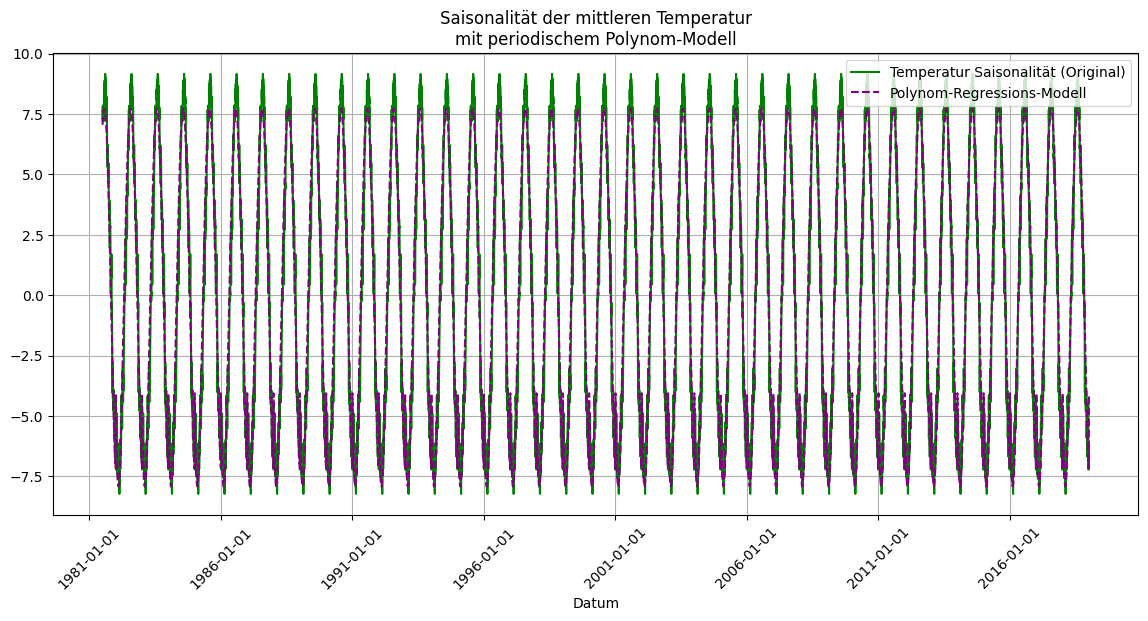

In [74]:
# Tag des Jahres für alle Daten
day_of_year_all = df_train.index.dayofyear.values.reshape(-1, 1)
X_poly_all = poly.transform(day_of_year_all)

season_pred_all = temp_season_model.predict(X_poly_all)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_season'], label='Temperatur Saisonalität (Original)', color='green')
plt.plot(df_train.index, season_pred_all, label='Polynom-Regressions-Modell', color='purple', linestyle='--')
plt.xlabel("Datum")
plt.xticks(xticks, rotation=45)
plt.title("Saisonalität der mittleren Temperatur\nmit periodischem Polynom-Modell")
plt.grid(True)
plt.legend()
plt.show()


### Modellieren Residuen Temperatur
Aus der ACF und PACF der Residuen der Temperaturkomponente haben wir erkannt, dass ein AR(3)-Modell passend wäre. Daher modellieren wir die Residuen der Temperatur mit einem AR(3)-Modell.

c:\Users\adria\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


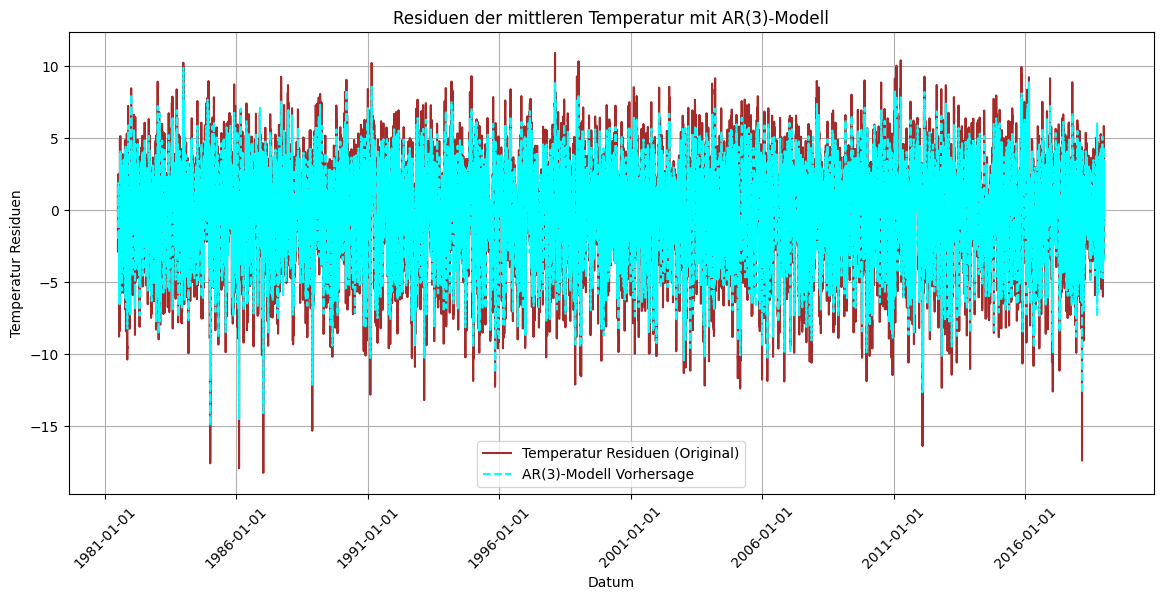

In [75]:
# Modellieren der Residuen mit einem AR(3)-Modell
from statsmodels.tsa.ar_model import AutoReg
temp_resid_model = AutoReg(df_train['temp_resid'], lags=3).fit()
resid_pred = temp_resid_model.predict(start=0, end=len(df_train)-1)
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_resid'], label='Temperatur Residuen (Original)', color='brown')
plt.plot(df_train.index, resid_pred, label='AR(3)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Temperatur Residuen')
plt.title('Residuen der mittleren Temperatur mit AR(3)-Modell')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()

## Zusammensetzung der Temperaturkomponenten
Nun müssen die einzelnen modellierten Komponenten der Temperatur wieder zusammengesetzt werden, um die gesamte Temperatur zu erhalten. Dies geschieht durch Addition der modellierten Trend-, Saisonalitäts- und Residuenkomponenten. Die Werte sollen anschliessend auch dafür benutzt werden, um zukünftige Temperaturen vorherzusagen.

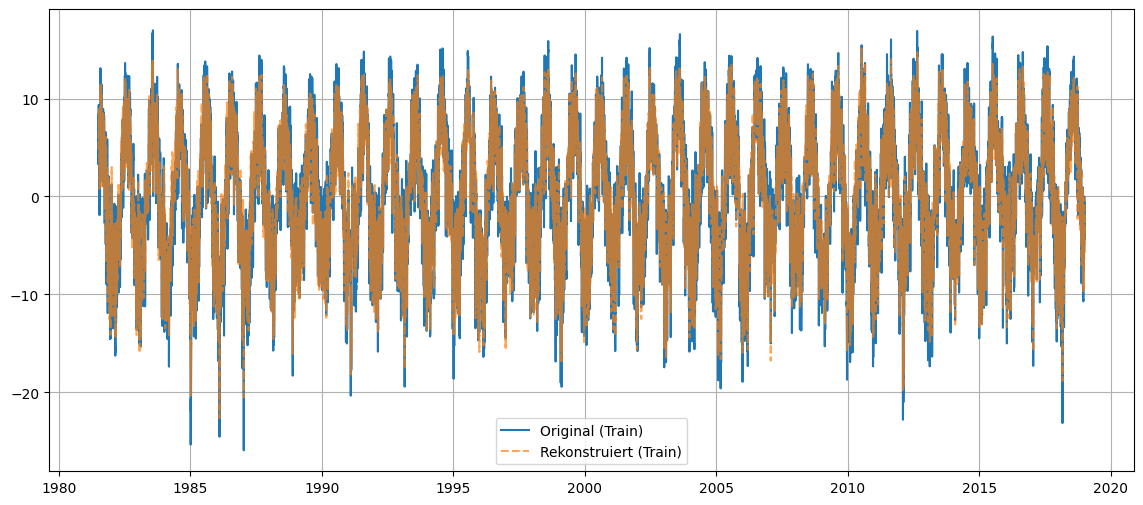

In [ ]:
# Trend vorhersagen
X_train_days = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
temp_trend_train_pred = temp_trend_model.predict(X_train_days)

# Saisonalität vorhersagen
day_of_year_train = df_train.index.dayofyear.values.reshape(-1, 1)
temp_season_train_pred = poly.transform(day_of_year_train)
temp_season_train_pred = temp_season_model.predict(temp_season_train_pred)

# Residuen vorhersagen
temp_resid_train_pred = temp_resid_model.predict(start=df_train.index[0], end=df_train.index[-1])
# Gesamte Temperatur rekonstruieren
temp_train_reconstructed = temp_trend_train_pred + temp_season_train_pred + temp_resid_train_pred.values

# Plotten der rekonstruierten Temperatur gegen die Originalwerte
plt.figure(figsize=(14,6))
plt.plot(df_train.index, df_train['temp_trend'] + df_train['temp_season'] + df_train['temp_resid'], 
         label='Original (Train)', alpha=1)
plt.plot(df_train.index, temp_train_reconstructed, 
         label='Rekonstruiert (Train)', linestyle='--', alpha=0.7)
plt.legend()
plt.grid(True)
plt.show()

In der Rekonstruktion sieht man, dass einige Informationen verloren gehen, aber die Daten grundsätzlich gut rekonstruiert werden können. Nun noch die Vorhersagen in die Zukunft auf dem Testset anwenden.

c:\Users\adria\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


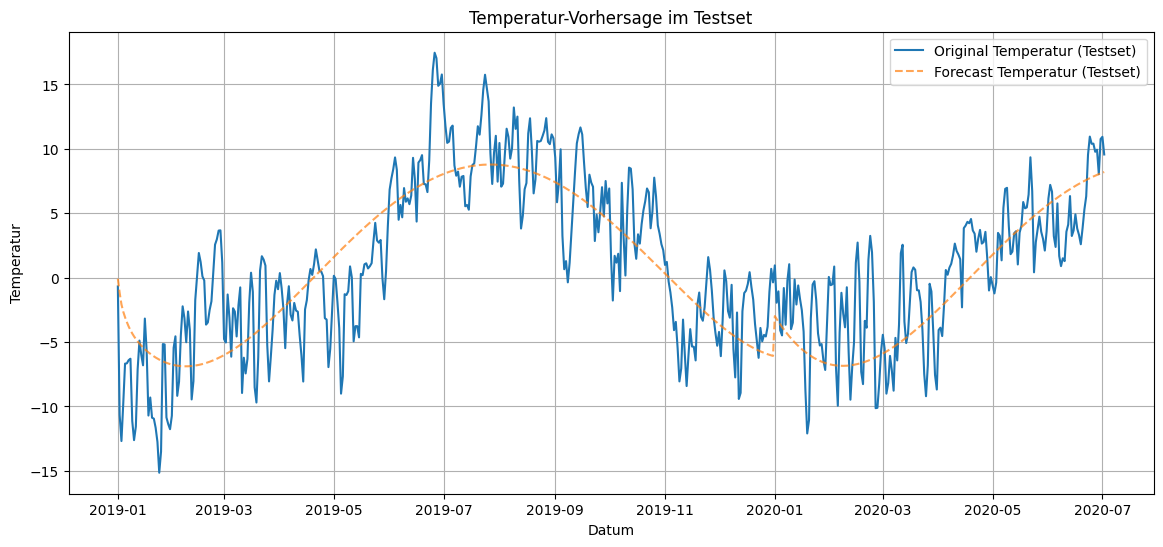

MAE: 3.065811548233154
RMSE: 3.779929909396487


In [ ]:
# -----------------------------
# Trend für das Testset vorhersagen
# -----------------------------
X_test_days = (df_test.index - df_train.index.min()).days.values.reshape(-1, 1)
temp_trend_test_pred = temp_trend_model.predict(X_test_days)

# -----------------------------
# Saisonalität für das Testset vorhersagen
# -----------------------------
day_of_year_test = df_test.index.dayofyear.values.reshape(-1, 1)
X_poly_test = poly.transform(day_of_year_test)
temp_season_test_pred = temp_season_model.predict(X_poly_test)

# -----------------------------
# Residuen für das Testset vorhersagen (AR(3))
# -----------------------------
# Wichtig: dynamic=True, damit zukünftige Werte korrekt rekursiv berechnet werden

temp_resid_test_pred = temp_resid_model.predict(
    start=df_test.index[0],  # erster Testtag
    end=df_test.index[-1],   # letzter Testtag
    dynamic=True             # rekursive Vorhersage für zukünftige Tage
)

# -----------------------------
# Gesamte Temperatur rekonstruieren
# -----------------------------
temp_test_forecast = temp_trend_test_pred + temp_season_test_pred + temp_resid_test_pred.values

# -----------------------------
# Visualisierung: Original vs. Forecast
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(df_test.index,
         df_test['temp_trend'] + df_test['temp_season'] + df_test['temp_resid'],
         label='Original Temperatur (Testset)', alpha=1)
plt.plot(df_test.index,
         temp_test_forecast,
         label='Forecast Temperatur (Testset)', linestyle='--', alpha=0.7)
plt.xlabel("Datum")
plt.ylabel("Temperatur")
plt.title("Temperatur-Vorhersage im Testset")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Fehlerkennzahlen
# -----------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = df_test['temp_trend'] + df_test['temp_season'] + df_test['temp_resid']
y_pred = temp_test_forecast

print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Die Rekonstruktion der gesamten Temperatur auf dem Testset erfolgt durch Addition der vorhergesagten Trend-, Saisonalitäts- und Residuenkomponenten. Sie sieht in ordnung aus. Jedoch wird klar, dass ein grosser Teil der Rekonstruktion durch die Saisonalität kommt. Das liegt aber daranm, dass die Saisonalität den grössten Anteil an der Varianz der Temperatur hat und das AR(3)-Modell nur zu beginn der Testperiode gut vorhersagen kann. Der Trend hat insgesammt nur einen sehr kleinen Einfluss auf die Temperatur. Es ist deshalb wichtig zu wissen, dass man für genauere Vorhersagen jeweils nur gerade die nächsten Tage vorhersagen kann, da das AR-Modell nur auf den letzten Werten basiert.

# Modellieren des Niederschlags
Aufgrund der schlechten Daten und der kleinen Korrelation zum Wasserstand haben wir uns entschieden, den Niederschlag vorerst nicht zu modellieren und für die Vorhersage zu benutzen.

# Modellierung des Abflussvolumens
## Modellieren Trend Abflussvolumen

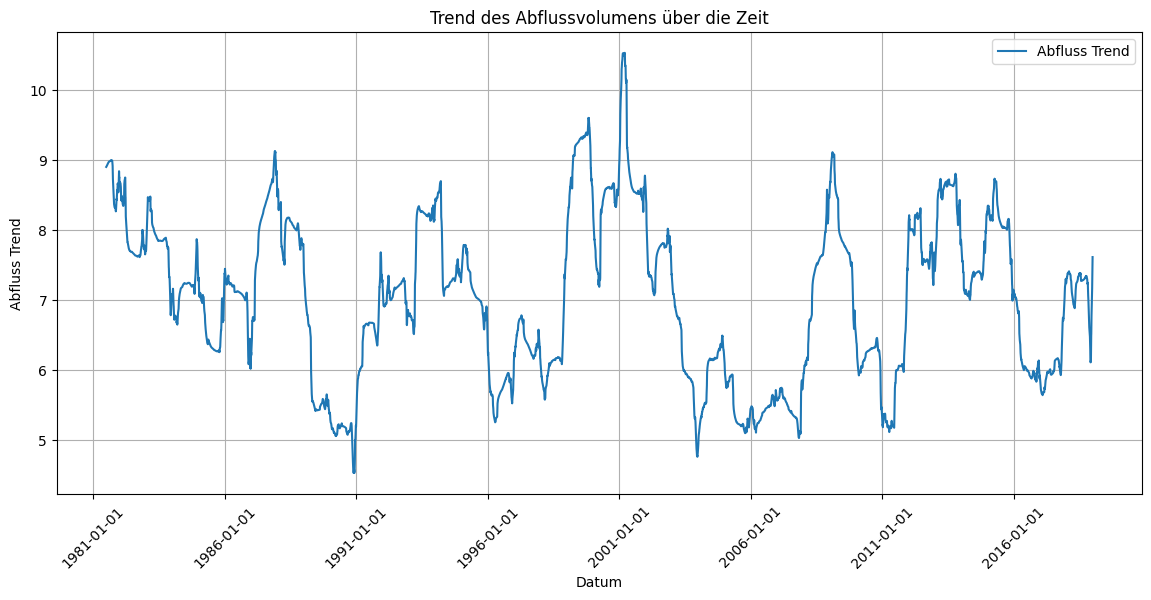

In [98]:
# Trend des Abfluss modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_trend'], label='Abfluss Trend')
plt.xlabel('Datum')
plt.ylabel('Abfluss Trend')
plt.title('Trend des Abflussvolumens über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

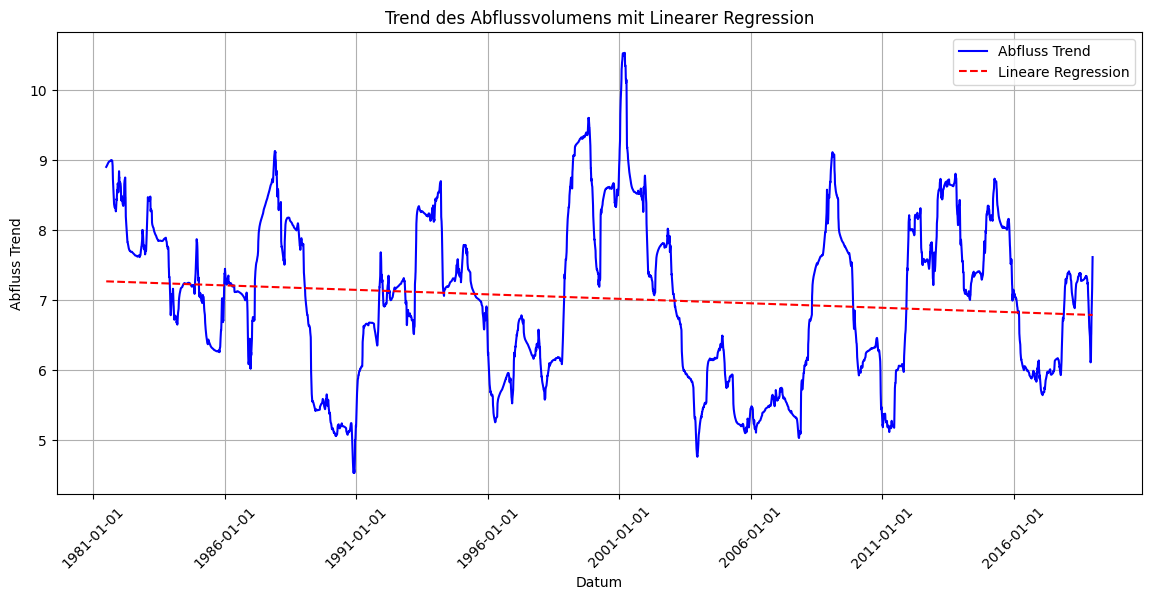

In [108]:
# Feature: Tage seit Startdatum
X = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
y = df_train['discharge_trend'].values

# Lineare Regression auf polynomiale Features
discharge_trend_model = LinearRegression()
discharge_trend_model.fit(X, y)

# Vorhersage
discharge_trend_pred = discharge_trend_model.predict(X)

# Plotten
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_trend'], label='Abfluss Trend', color='blue')
plt.plot(df_train.index, discharge_trend_pred, label='Lineare Regression', color='red', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Abfluss Trend')
plt.title('Trend des Abflussvolumens mit Linearer Regression')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()


Die Daten sind nicht sonderlich gut zu reproduzieren mit einfachen linearen Modellen. Jedoch verzichten wir hier fürs erste auf weitere Trendanalysen.

## Modellieren Saisonalität Abflussvolumen

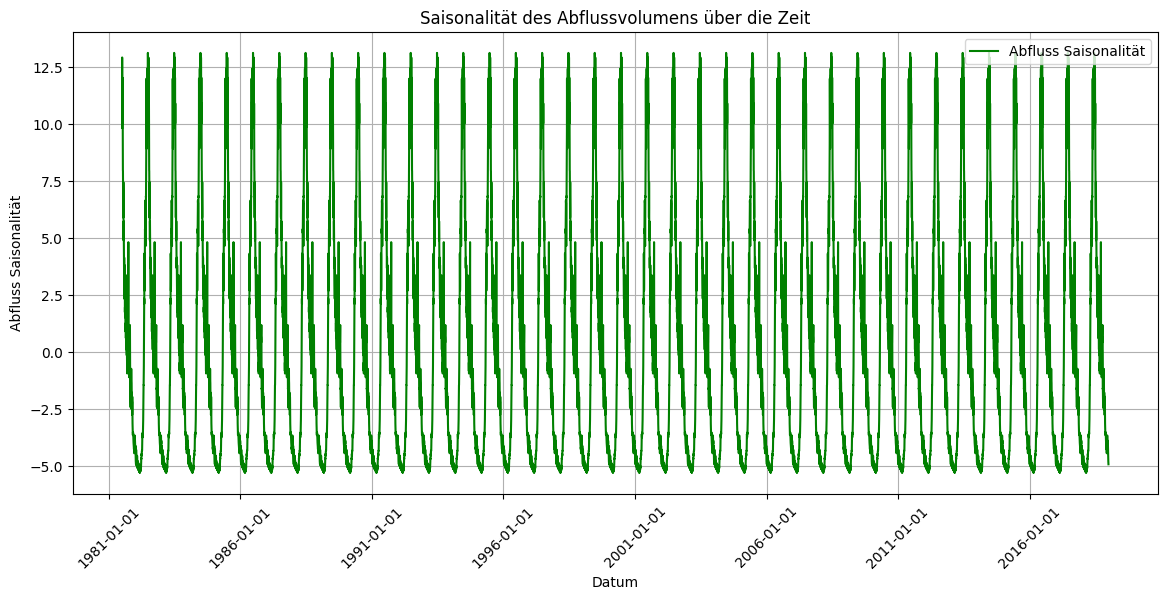

In [109]:
# Plotten der Saisonalität des Abflussvolumens
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_season'], label='Abfluss Saisonalität', color='green')
plt.xlabel('Datum')
plt.ylabel('Abfluss Saisonalität')
plt.title('Saisonalität des Abflussvolumens über die Zeit')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()

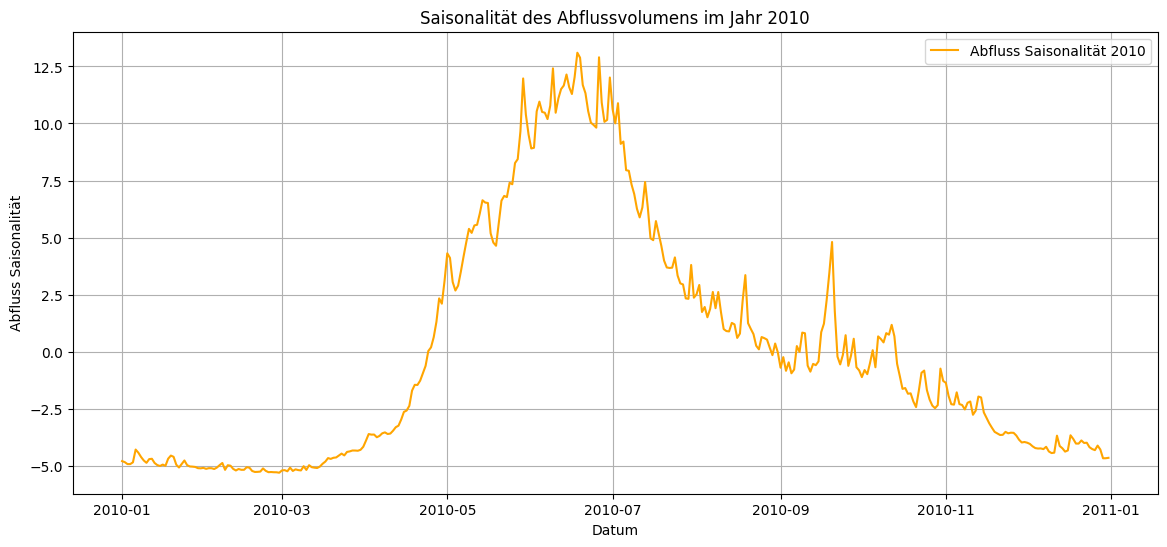

In [110]:
# Welle für ein Jahr plotten
plt.figure(figsize=(14, 6))
one_year = df_train['discharge_season']['2010-01-01':'2010-12-31']
plt.plot(one_year.index, one_year.values, label='Abfluss Saisonalität 2010', color='orange')
plt.xlabel('Datum')
plt.ylabel('Abfluss Saisonalität')
plt.title('Saisonalität des Abflussvolumens im Jahr 2010')
plt.grid(True)
plt.legend()
plt.show()

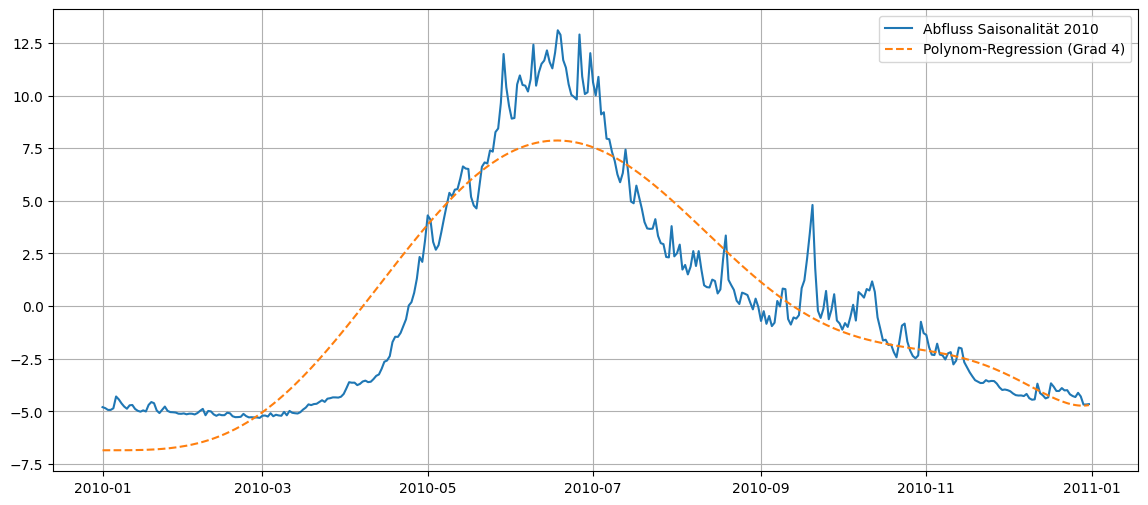

In [ ]:
# Fitten einer Polynom-Regression für eine Welle eines Jahres
one_year = df_train['discharge_season']['2010-01-01':'2010-12-31']
poly = PolynomialFeatures(degree=8)
X_poly = poly.fit_transform(day_of_year)

seasonal_season_model = LinearRegression()
seasonal_season_model.fit(X_poly, one_year.values)

season_pred = seasonal_season_model.predict(X_poly)

plt.figure(figsize=(14, 6))
plt.plot(one_year.index, one_year.values, label='Abfluss Saisonalität 2010')
plt.plot(one_year.index, season_pred, label='Polynom-Regression (Grad 8)', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()